In [2]:
from google.colab import files
uploaded = files.upload()

Saving penguins.csv to penguins.csv


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_

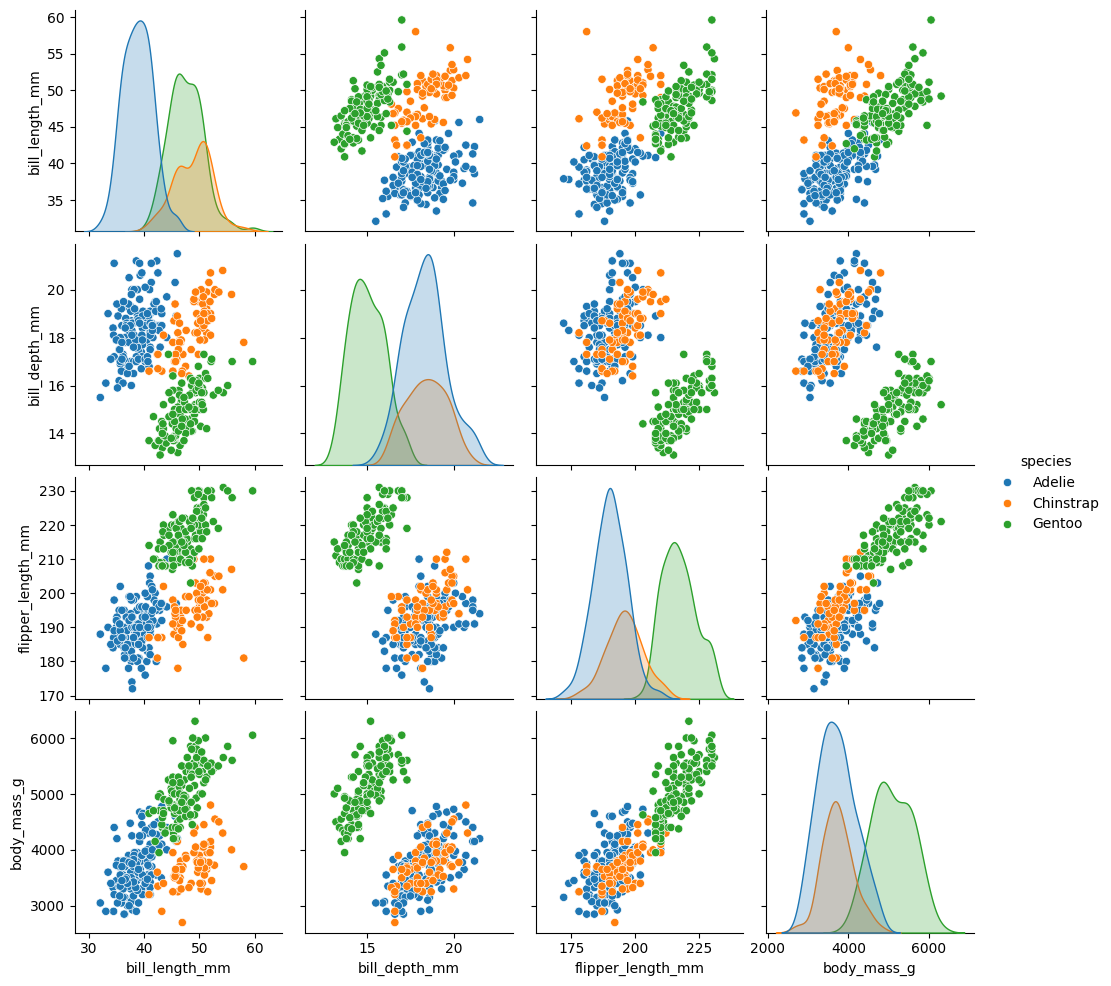

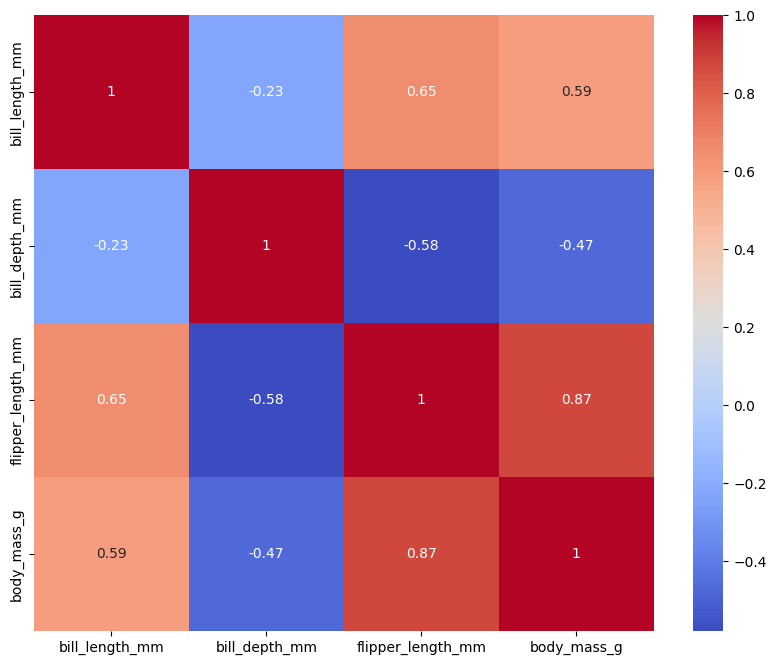

Error cuadrático medio (regresión lineal): 137599.06118761664
Precisión (regresión logística): 0.9850746268656716
[[30  1  0]
 [ 0 13  0]
 [ 0  0 23]]


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

df = pd.read_csv('penguins.csv')

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

df = df.dropna()

sns.pairplot(df, hue='species', diag_kind='kde')
plt.show()

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# REGRESIÓN LINEAL

X_linear = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']]
y_linear = df['body_mass_g']

X_train, X_test, y_train, y_test = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Error cuadrático medio (regresión lineal):",
      mean_squared_error(y_test, y_pred_linear))


# REGRESIÓN LOGÍSTICA
df['species'] = df['species'].astype('category').cat.codes

X_logistic = df[['bill_length_mm', 'bill_depth_mm',
                 'flipper_length_mm', 'body_mass_g']]

y_logistic = df['species']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_logistic, y_logistic, test_size=0.2, random_state=42
)

logistic_model = LogisticRegression(max_iter=5000)
logistic_model.fit(X_train_log, y_train_log)

y_pred_logistic = logistic_model.predict(X_test_log)

print("Precisión (regresión logística):",
      accuracy_score(y_test_log, y_pred_logistic))
#
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test_log, y_pred_logistic))